#### Quantum patch GAN

We next demonstrate how to implement a quantum patch GAN introduced
in Chapter 4.3.3 for the generation of hand-written digits of five. The whole
pipeline includes the following steps:
Step 1 Load and pre-process the dataset.
Step 2 Build the classical discriminator.
Step 3 Build the quantum generator.
Step 4 Train the quantum patch GAN.
Step 5 Visualize the generated images.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import math

Step 1: Dataset preparation. 

In [2]:
class OptdigitsData(Dataset):
    def __init__(self, data_path, label, max_samples=None):
        """
        Dataset class for Optical Recognition of
        Handwritten Digits.
        """
        super().__init__()
        self.data = []
        with open(data_path, 'r') as f:
            for line in f.readlines():
                if int(line.strip().split(',')[-1]) == label:
                    # Normalize image pixel values from [0,16) to [0, 1)
                    image = [int(pixel) / 16 for pixel in line.strip().split(',')[:-1]]
                    image = np.array(image, dtype=np.float32).reshape(8, 8)
                    self.data.append(image)
                    if max_samples is not None and len(self.data) >= max_samples:
                        break
        self.label = label

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return torch.from_numpy(self.data[index]), self.label

<string>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


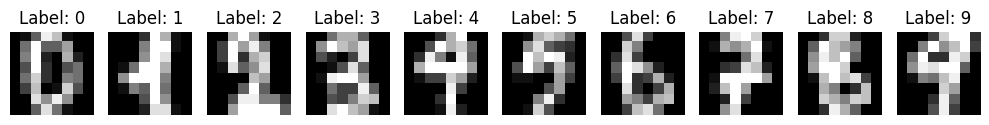

In [3]:
def visualize_dataset(data_path):
    """
    Visualizes the dataset by displaying examples for
    each digit label.
    """
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        data = OptdigitsData(data_path, label=i)
        plt.imshow(data[0][0], cmap='gray')
        plt.title(f'Label: {i}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_dataset('code/chapter5_qnn/data/optdigits.tra')

Step 2: Building the classical discriminator.

In [4]:
class ClassicalDiscriminator(nn.Module):
    """
    A classical discriminator for classifying real and fake images.
    """
    def __init__(self, input_shape):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(int(np.prod(input_shape)), 256),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

Step 3: Defining the quantum patch generator.

In [5]:
def PQC(params):
    n_layer, n_qubit = params.shape[0], params.shape[1]
    for i in range(n_layer):
        for j in range(n_qubit):
            qml.Rot(params[i, j, 0], params[i, j, 1], params[i, j, 2], wires=j)
        # Control Z gates
        for j in range(n_qubit - 1):
            qml.CZ(wires=[j, j + 1])

In [6]:
def QuantumGenerator(params, z=None, n_qubit_a=1):
    n_qubit = params.shape[1]

    # angle encoding of latent state z
    for i in range(n_qubit):
        qml.RY(z[i], wires=i)
    PQC(params)
    # partial measurement on the ancillary qubits
    qml.measure(wires=n_qubit - 1)
    return qml.probs(wires=range(n_qubit - n_qubit_a))

In [7]:
class PatchQuantumGenerator(nn.Module):
    """
    Combines patches generated by quantum circuits into full images.
    """
    def __init__(self, qnode_generator, n_generator, n_qubit, n_qubit_a, n_layer):
        super().__init__()
        self.params_generator = nn.ParameterList([
            nn.Parameter(torch.rand((n_layer, n_qubit, 3)), requires_grad=True)
            for _ in range(n_generator)
        ])
        self.qnode_generator = qnode_generator
        self.n_qubit_a = n_qubit_a

    def forward(self, zs):
        images = []
        for z in zs:
            patches = []
            for params in self.params_generator:
                patch = self.qnode_generator(params, z=z, n_qubit_a=self.n_qubit_a).float()
                # post-processing: min-max scaling
                patch = (patch - patch.min()) / (patch.max() - patch.min() + 1e-8)
                patches.append(patch.unsqueeze(0))
            patches = torch.cat(patches, dim=0)
            images.append(patches.flatten().unsqueeze(0))
        return torch.cat(images, dim=0)

Step 4: Training the quantum patch GAN

In [8]:
# Hyperparameters
torch.manual_seed(0)
image_width = 8
image_height = 8
n_generator = 4
n_qubit_d = int(np.log2((image_width * image_height) // n_generator))
n_qubit_a = 1
n_qubit = n_qubit_d + n_qubit_a
n_layer = 6

# Quantum device
dev = qml.device('lightning.qubit', wires=n_qubit)
qnode_generator = qml.QNode(QuantumGenerator, dev)

# Initialize generator and discriminator
discriminator = ClassicalDiscriminator([image_height, image_width])
discriminator.train()
generator = PatchQuantumGenerator(qnode_generator, n_generator, n_qubit, n_qubit_a, n_layer)
generator.train()

# Optimizers
lr_generator = 0.3
lr_discriminator = 1e-2
opt_discriminator = optim.SGD(discriminator.parameters(), lr=lr_discriminator)
opt_generator = optim.SGD(generator.parameters(), lr=lr_generator)

# Construct dataset and dataloader
batch_size = 4
dataset = OptdigitsData('code/chapter5_qnn/data/optdigits.tra', label=5, max_samples=20)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Loss function
loss_fn = nn.BCELoss()
labels_real = torch.ones(batch_size, dtype=torch.float)
labels_fake = torch.zeros(batch_size, dtype=torch.float)

# Testing setup
n_test = 10
z_test = torch.rand(n_test, n_qubit) * math.pi

In [9]:
n_epoch = 5
record = {}
for i in range(n_epoch):
    for data, _ in dataloader:
        zs = torch.rand(batch_size, n_qubit) * math.pi
        image_fake = generator(zs)
        # Training the discriminator
        discriminator.zero_grad()
        pred_fake = discriminator(image_fake.detach())
        pred_real = discriminator(data)
        loss_discriminator = loss_fn(pred_fake.squeeze(), labels_fake) + loss_fn(pred_real.squeeze(), labels_real)
        loss_discriminator.backward()
        opt_discriminator.step()
        # Training the generator
        generator.zero_grad()
        pred_fake = discriminator(image_fake)
        loss_generator = loss_fn(pred_fake.squeeze(), labels_real)
        loss_generator.backward()
        opt_generator.step()
    print(f'The {i}-th epoch: discriminator loss= {loss_discriminator:0.3f}, generator loss= {loss_generator:0.3f}')
    # test
    generator.eval()
    image_generated = generator(z_test).view(n_test, image_height, image_width).detach()
    record[str(i)] = {
        'loss_discriminator': loss_discriminator.item(),
        'loss_generator': loss_generator.item(),
        'image_generated': image_generated.numpy().tolist()
    }
    generator.train()

The 0-th epoch: discriminator loss= 1.377, generator loss= 0.722
The 1-th epoch: discriminator loss= 1.362, generator loss= 0.714
The 2-th epoch: discriminator loss= 1.344, generator loss= 0.700
The 3-th epoch: discriminator loss= 1.346, generator loss= 0.735
The 4-th epoch: discriminator loss= 1.321, generator loss= 0.703


Step 5: Visualizing the generated images. 

In [10]:
n_epochs_to_visualize = (len(record) + 1) // 2
n_images_per_epoch = 10

fig, axes = plt.subplots(n_epochs_to_visualize, n_images_per_epoch, figsize=(n_images_per_epoch, n_epochs_to_visualize))

# Iterate through the recorded epochs and visualize generated images
for epoch_idx, (epoch, data) in enumerate(record.items()):
    if epoch_idx % 2 == 1:
        continue
    images = np.array(data['image_generated'])
    for img_idx in range(n_images_per_epoch):
        ax = axes[epoch_idx // 2, img_idx]
        ax.imshow(images[img_idx], cmap='gray')
        ax.axis('off')
        # Add epoch information to the title of each row
        if img_idx == 0:
            ax.set_title(f'Epoch {epoch}', fontsize=10)
plt.tight_layout()
plt.show()

IndexError: index 2 is out of bounds for axis 0 with size 2